AllenNLP not available. Registrable won't work.


Epoca 40/200 | Loss Media Batch: -0.5346
Epoca 80/200 | Loss Media Batch: -1.2296
Epoca 120/200 | Loss Media Batch: -1.4899
Epoca 160/200 | Loss Media Batch: -1.6604
Epoca 200/200 | Loss Media Batch: -1.7911


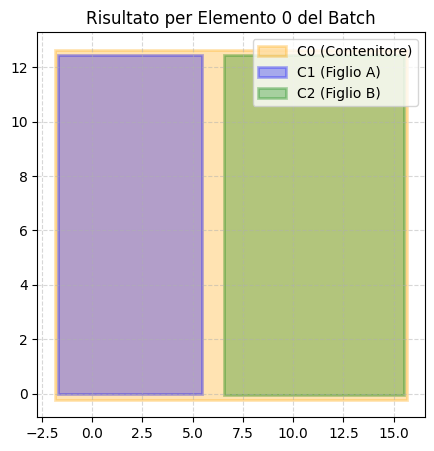

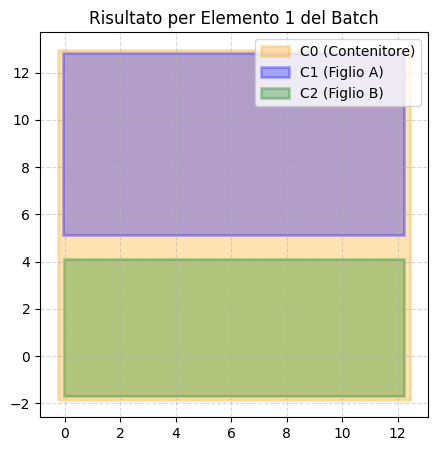

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from box_embeddings.parameterizations import MinDeltaBoxTensor
from box_embeddings.modules.intersection import GumbelIntersection
from box_embeddings.modules.volume import SoftVolume

# --- 1. SETUP DEL BATCH ---
num_concepts = 3
num_dims = 2
feature_dim = 64
batch_size = 4  # ORA ADDESTRIAMO SU UN BATCH DI 4 ELEMENTI!

torch.manual_seed(42)
# Generiamo 4 vettori di feature diversi
features = torch.randn(batch_size, feature_dim)

projectors = nn.ModuleList([
    nn.Linear(in_features=feature_dim, out_features=2 * num_dims), # C0
    nn.Linear(in_features=feature_dim, out_features=2 * num_dims), # C1
    nn.Linear(in_features=feature_dim, out_features=2 * num_dims)  # C2
])

optimizer = torch.optim.Adam(projectors.parameters(), lr=0.01)

gumbel_intersection = GumbelIntersection(intersection_temperature=0.1)
soft_volume = SoftVolume(volume_temperature=0.5)

# --- 2. GROUND TRUTH ---
supervisions = [
    (0, 1, 1.0),
    (0, 2, 1.0),
    (1, 2, 0.0),
    (2, 1, 0.0),
]

# --- 3. FUNZIONE DI VISUALIZZAZIONE PER BATCH ---
def plot_boxes(boxes_dict, batch_idx, title):
    fig, ax = plt.subplots(figsize=(5, 5))
    colors = ['orange', 'blue', 'green']
    labels = ['C0 (Contenitore)', 'C1 (Figlio A)', 'C2 (Figlio B)']
    
    for i in range(num_concepts):
        # Estraiamo le coordinate SPECIFICHE per l'elemento del batch richiesto
        z_coords = boxes_dict[i].z[batch_idx].detach().numpy()
        Z_coords = boxes_dict[i].Z[batch_idx].detach().numpy()
        
        width = Z_coords[0] - z_coords[0]
        height = Z_coords[1] - z_coords[1]
        
        rect = patches.Rectangle((z_coords[0], z_coords[1]), width, height, 
                                 linewidth=2, edgecolor=colors[i], facecolor=colors[i], 
                                 alpha=0.3, label=labels[i])
        ax.add_patch(rect)
        
    ax.autoscale_view()
    plt.legend()
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- 4. LOOP DI ADDESTRAMENTO ---
epochs = 200 

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # 1. Proiezioni in batch. Ogni theta ha shape: (batch_size, 4)
    theta_0 = projectors[0](features)
    theta_1 = projectors[1](features)
    theta_2 = projectors[2](features)
    
    # 2. Reshape e Creazione dei Box individuali
    # Shape di ogni box_tensor diventerà: (batch_size, 2, 2)
    box_0 = MinDeltaBoxTensor(theta_0.view(batch_size, 2, num_dims))
    box_1 = MinDeltaBoxTensor(theta_1.view(batch_size, 2, num_dims))
    box_2 = MinDeltaBoxTensor(theta_2.view(batch_size, 2, num_dims))
    
    # Li mettiamo in un dizionario per comodità
    boxes = {0: box_0, 1: box_1, 2: box_2}
    
    total_loss = 0.0
    
    for target_id, source_id, target_prob in supervisions:
        b_target = boxes[target_id]
        b_source = boxes[source_id]
        
        int_box = gumbel_intersection(b_target, b_source)
        
        # log_vol_int avrà shape: (batch_size,)
        log_vol_int = soft_volume(int_box)
        log_vol_source = soft_volume(b_source)
        
        pred_prob = torch.exp(log_vol_int - log_vol_source)
        pred_prob = torch.clamp(pred_prob, 1e-6, 1.0 - 1e-6)
        
        # 3. Creiamo un tensore target lungo quanto il batch (es. [1.0, 1.0, 1.0, 1.0])
        target_tensor = torch.full((batch_size,), target_prob, dtype=torch.float32)
        
        # BCE calcola in automatico la media (mean) della loss sul batch
        loss = F.binary_cross_entropy(pred_prob, target_tensor)
        total_loss += loss
    
    # Contromisura Anti-Collasso: prendiamo la media dei volumi sul batch
    vol_loss = -0.2 * (soft_volume(box_1).mean() + soft_volume(box_2).mean())

    final_loss = total_loss + vol_loss
    final_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 40 == 0:
        print(f"Epoca {epoch + 1}/{epochs} | Loss Media Batch: {final_loss.item():.4f}")

# Visualizziamo i risultati per due elementi diversi del batch a fine addestramento
# Ricalcoliamo l'ultimo forward
with torch.no_grad():
    t0 = projectors[0](features).view(batch_size, 2, num_dims)
    t1 = projectors[1](features).view(batch_size, 2, num_dims)
    t2 = projectors[2](features).view(batch_size, 2, num_dims)
    final_boxes = {0: MinDeltaBoxTensor(t0), 1: MinDeltaBoxTensor(t1), 2: MinDeltaBoxTensor(t2)}

plot_boxes(final_boxes, batch_idx=0, title="Risultato per Elemento 0 del Batch")
plot_boxes(final_boxes, batch_idx=1, title="Risultato per Elemento 1 del Batch")

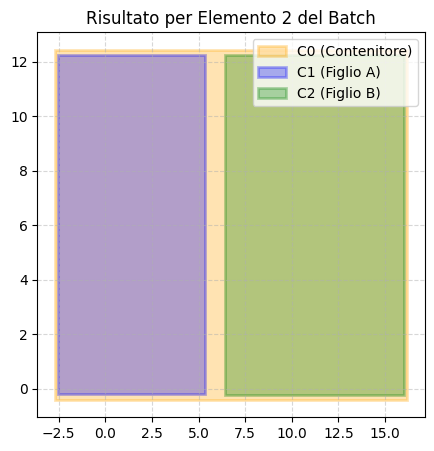

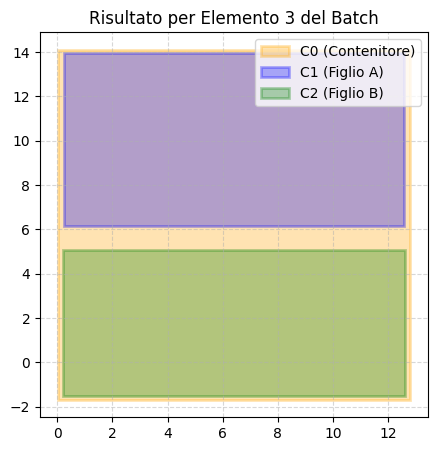

In [2]:
plot_boxes(final_boxes, batch_idx=2, title="Risultato per Elemento 2 del Batch")
plot_boxes(final_boxes, batch_idx=3, title="Risultato per Elemento 3 del Batch")